In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as torch_F
import torch.optim as optim
from torchcfm.conditional_flow_matching import VariancePreservingConditionalFlowMatcher
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, mean_absolute_error

# --- [1. Configuration] ---
device = "mps" if torch.backends.mps.is_available() else "cpu"
d = 2                # Predator-Prey (Prey, Predator)
N_steps = 1000       
n_dataset = 10000    
K = 20               
T_total = 1.0
t_path = np.linspace(0, T_total, N_steps + 1)
t_inc = t_path[:-1]

N_coeffs = 2 * K + 1
M_per_dim = 1 + 2 * N_coeffs
M_total = d * M_per_dim
batch_size = 128
num_epochs = 200
lr = 1e-4

# --- [2. Fourier Encoding & Decoding] ---

def path_encoding_refined(paths, t_points, K, T):
    B, _, D = paths.shape
    increments = np.diff(paths, axis=1) 
    x0 = paths[:, 0, :]                 
    omega0 = 2 * np.pi / T
    freq_indices = np.arange(-K, K + 1)
    exp_mat = np.exp(-1j * omega0 * np.outer(t_points, freq_indices))
    coeffs = np.einsum('bnd,nk->bdk', increments, exp_mat)
    real_part, imag_part = np.real(coeffs), np.imag(coeffs)
    combined = []
    for i in range(D):
        combined.append(x0[:, i:i+1])
        combined.append(real_part[:, i, :])
        combined.append(imag_part[:, i, :])
    return np.concatenate(combined, axis=1)

def path_decoding_refined(vector_flat, t_points_full, T, d, K):
    omega0 = 2 * np.pi / T
    freq_indices = np.arange(-K, K + 1)
    N_coeffs, M_per_dim = 2 * K + 1, 1 + 2 * (2 * K + 1)
    reconstructed_path = np.zeros((len(t_points_full), d))
    for i in range(d):
        segment = vector_flat[i * M_per_dim : (i + 1) * M_per_dim]
        x0_val = segment[0]
        coeffs = segment[1 : 1 + N_coeffs] + 1j * segment[1 + N_coeffs:]
        recon_inc = np.zeros(len(t_points_full), dtype=complex)
        for idx, k in enumerate(freq_indices):
            val = coeffs[idx]
            if k == 0: recon_inc += val * t_points_full / T
            else: recon_inc += val * (np.exp(1j * k * omega0 * t_points_full) - 1) / (1j * k * omega0)
        reconstructed_path[:, i] = x0_val + np.real(recon_inc)
    return reconstructed_path

# --- [3. Predator-Prey Dataset Generation] ---

def generate_predator_prey(no, seq_len):
    """Method from https://github.com/morganstanley/MSML/blob/main/papers/Stochastic_Process_Diffusion/tsdiff/data/generate.py."""
    class PredatorPrey(nn.Module):
        def forward(self, t, y):
            y1, y2 = y.chunk(2, dim=-1)
            dy = torch.cat([2/3 * y1 - 4/3 * y1 * y2, 1.0 * y1 * y2 - 1.0 * y2], -1)
            return dy
    y0 = torch.rand(no, 2) + 0.5 
    t_space = torch.linspace(0, 15, seq_len)
    with torch.no_grad():
        out = odeint(PredatorPrey(), y0, t_space, method='rk4').permute(1, 0, 2)
    data_min, data_max = out.min(), out.max()
    return ((out - data_min) / (data_max - data_min)).cpu().numpy()

print(f"Generating {n_dataset} paths...")
paths = generate_predator_prey(n_dataset, N_steps + 1)
F_raw = path_encoding_refined(paths, t_inc, K, T_total)
F_tensor = torch.from_numpy(F_raw).float().to(device)
mu, sigma = F_tensor.mean(dim=0), F_tensor.std(dim=0) + 1e-6
F_norm = (F_tensor - mu) / sigma
dataloader = DataLoader(TensorDataset(F_norm), batch_size=batch_size, shuffle=True)

# --- [4. Flow Matcher Architecture] ---

class FlowNetTransformerToken(nn.Module):
    def __init__(self, features_per_dim, num_dims, num_layers=4, num_heads=8, hidden_dim=512):
        super().__init__()
        self.f_dim, self.num_dims = features_per_dim, num_dims
        self.input_proj = nn.Linear(features_per_dim, hidden_dim)
        self.t_embed = nn.Sequential(nn.Linear(1, hidden_dim // 4), nn.SiLU(), nn.Linear(hidden_dim // 4, hidden_dim))
        self.dim_embed = nn.Parameter(torch.randn(1, num_dims, hidden_dim))
        layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim*4, dropout=0.1, activation='gelu', batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.output_proj = nn.Linear(hidden_dim, features_per_dim)

    def forward(self, t, x):
        b = x.shape[0]
        x = x.view(b, self.num_dims, self.f_dim)
        h = self.input_proj(x) + self.t_embed(t.view(-1, 1)).unsqueeze(1) + self.dim_embed
        return self.output_proj(self.transformer(h)).view(b, -1)

model = FlowNetTransformerToken(M_per_dim, d).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
cfm = VariancePreservingConditionalFlowMatcher(sigma=0.01)

# --- [5. Training] ---
model.train()
for epoch in tqdm(range(num_epochs), desc="Training Flow"):
    for batch in dataloader:
        x1 = batch[0]
        x0_noise = torch.randn_like(x1)
        t, xt, ut = cfm.sample_location_and_conditional_flow(x0_noise, x1)
        loss = torch_F.mse_loss(model(t, xt), ut)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

# --- [6. Integrated Evaluator Functions] ---

class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Discriminator, self).__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x, seq_lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, seq_lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        return self.fc(hidden[-1])

class Predictor(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Predictor, self).__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        outputs, _ = self.rnn(x)
        return torch.sigmoid(self.fc(outputs))

def discriminative_score_metrics(ori_data, generated_data):
    """Inspired by the implementation in SigDiffusions.
    
    Reference: B. Barancikova, Z. Huang, and C. Salvi. SigDiffusions: 
    Score-Based Diffusion Models for Long Time Series via Log-Signature Embeddings. 2024. arXiv: 2406.10354.

    Github repository: https://github.com/Barb0ra/SigDiffusions
    
    """
    no, seq_len, dim = ori_data.shape
    hidden_dim, iterations, batch_size = max(dim // 2, 2), 1200, 128
    
    # Simple split (replacing metric_utils dependency)
    split = int(no * 0.8)
    train_x, test_x = ori_data[:split], ori_data[split:]
    train_x_hat, test_x_hat = generated_data[:split], generated_data[split:]
    
    # Fixed lengths for this specific dataset
    train_t = torch.full((batch_size,), seq_len, dtype=torch.long).to(device)
    test_t_real = torch.full((len(test_x),), seq_len, dtype=torch.long).to(device)
    test_t_fake = torch.full((len(test_x_hat),), seq_len, dtype=torch.long).to(device)

    discriminator = Discriminator(dim, hidden_dim).to(device)
    optimizer = optim.Adam(discriminator.parameters())
    criterion = nn.BCEWithLogitsLoss()

    discriminator.train()
    for _ in tqdm(range(iterations), desc="Training Discriminator"):
        idx_real = np.random.choice(len(train_x), batch_size)
        idx_fake = np.random.choice(len(train_x_hat), batch_size)
        
        X_mb = torch.tensor(train_x[idx_real], dtype=torch.float32).to(device)
        X_hat_mb = torch.tensor(train_x_hat[idx_fake], dtype=torch.float32).to(device)

        optimizer.zero_grad()
        loss = criterion(discriminator(X_mb, train_t), torch.ones(batch_size, 1).to(device)) + \
               criterion(discriminator(X_hat_mb, train_t), torch.zeros(batch_size, 1).to(device))
        loss.backward(); optimizer.step()

    discriminator.eval()
    with torch.no_grad():
        y_pred_real = torch.sigmoid(discriminator(torch.tensor(test_x, dtype=torch.float32).to(device), test_t_real)).cpu().numpy()
        y_pred_fake = torch.sigmoid(discriminator(torch.tensor(test_x_hat, dtype=torch.float32).to(device), test_t_fake)).cpu().numpy()
    
    acc = accuracy_score(np.concatenate([np.ones(len(y_pred_real)), np.zeros(len(y_pred_fake))]), 
                         np.concatenate([y_pred_real, y_pred_fake]) > 0.5)
    return np.abs(0.5 - acc)

def predictive_score_metrics(ori_data, generated_data):
    """Inspired by the implementation in SigDiffusions.
    
    Reference: B. Barancikova, Z. Huang, and C. Salvi. SigDiffusions: 
    Score-Based Diffusion Models for Long Time Series via Log-Signature Embeddings. 2024. arXiv: 2406.10354.

    Github repository: https://github.com/Barb0ra/SigDiffusions
    
    """
    no, seq_len, dim = ori_data.shape
    hidden_dim, iterations, batch_size = max(dim // 2, 2), 1200, 128
    model = Predictor(input_dim=dim-1, hidden_dim=hidden_dim).to(device)
    optimizer, criterion = optim.Adam(model.parameters()), nn.L1Loss()

    model.train()
    for _ in tqdm(range(iterations), desc="Training Predictor"):
        idx = np.random.choice(len(generated_data), batch_size)
        X_mb = torch.tensor(generated_data[idx, :-1, :dim-1], dtype=torch.float32).to(device)
        Y_mb = torch.tensor(generated_data[idx, 1:, dim-1:], dtype=torch.float32).to(device)
        
        optimizer.zero_grad()
        loss = criterion(model(X_mb), Y_mb)
        loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        X_test = torch.tensor(ori_data[:, :-1, :dim-1], dtype=torch.float32).to(device)
        Y_test = ori_data[:, 1:, dim-1:]
        pred_Y = model(X_test).cpu().numpy()
    
    return np.mean([mean_absolute_error(Y_test[i], pred_Y[i]) for i in range(no)])

# --- [7. Sampling & Evaluation] ---

def sample(model, n, mu, sigma):
    model.eval()
    with torch.no_grad():
        z0 = torch.randn(n, M_total).to(device)
        traj = odeint(lambda t, x: model(t.view(-1, 1), x), z0, torch.linspace(0, 1, 100).to(device), method='rk4')
        f_gen = (traj[-1] * sigma + mu).cpu().numpy()
    return np.array([path_decoding_refined(f, t_path, T_total, d, K) for f in f_gen])

gen_paths = sample(model, 2000, mu, sigma)
d_score = discriminative_score_metrics(paths[:2000], gen_paths)
p_score = predictive_score_metrics(paths[:2000], gen_paths)

print(f"\n--- Final Scores ---")
print(f"Discriminative Score: {d_score:.4f}")
print(f"Predictive Score:     {p_score:.4f}")



Generating 10000 paths...


Training Flow:   0%|          | 0/200 [00:00<?, ?it/s]

Training Discriminator:   0%|          | 0/1200 [00:00<?, ?it/s]

Training Predictor:   0%|          | 0/1200 [00:00<?, ?it/s]


--- Final Scores ---
Discriminative Score: 0.0225
Predictive Score:     0.0808


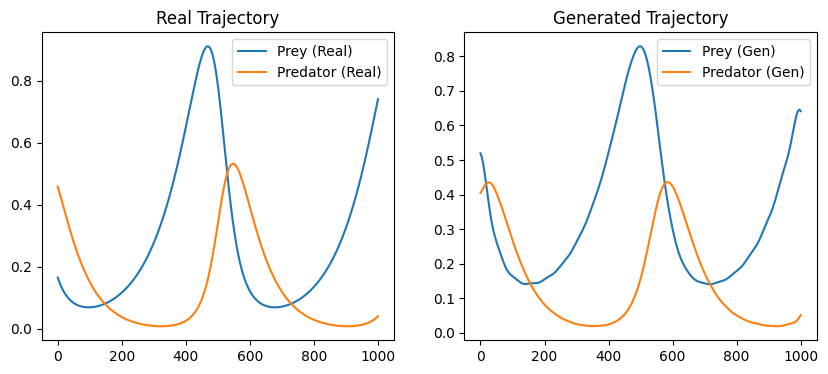

In [9]:
# Optional Visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(paths[0, :, 0], label="Prey (Real)")
plt.plot(paths[0, :, 1], label="Predator (Real)")
plt.title("Real Trajectory")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gen_paths[0, :, 0], label="Prey (Gen)")
plt.plot(gen_paths[0, :, 1], label="Predator (Gen)")
plt.title("Generated Trajectory")
plt.legend()
plt.show()

In [ ]:
from scipy.stats import ks_2samp

def get_ks_score_at_steps(real_data, fake_data, steps=[300, 500, 700, 900]):
    """Calculates KS scores."""
    step_scores = {}
    for step in steps:
        dim_scores = []
        for d_idx in range(real_data.shape[2]):
            # Compare distribution of real vs fake at index 'step' for dimension 'd_idx'
            stat, _ = ks_2samp(real_data[:, step, d_idx], fake_data[:, step, d_idx])
            dim_scores.append(stat)
        step_scores[step] = np.mean(dim_scores)
    
    avg_ks = np.mean(list(step_scores.values()))
    return avg_ks, step_scores

avg_ks, ks_details = get_ks_score_at_steps(paths[:2000], gen_paths)

print(f"Overall KS Average:   {avg_ks:.4f}")
print("-" * 25)
for t_step, val in ks_details.items():
    print(f"KS at t={t_step}:        {val:.4f}")

Overall KS Average:   0.1137
-------------------------
KS at t=300:        0.0777
KS at t=500:        0.1080
KS at t=700:        0.1913
KS at t=900:        0.0777
